In [ ]:
# ── Google Colab: монтируй диск ───────────
from google.colab import drive
drive.mount('/content/drive')

import os, warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import (GlobalAveragePooling2D, Dense,
                                      Dropout, BatchNormalization)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (ModelCheckpoint, EarlyStopping,
                                         ReduceLROnPlateau)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

Mounted at /content/drive


In [ ]:
# ──────────────────────────────────────────
#  ⚙️  НАСТРОЙКИ
# ──────────────────────────────────────────
DATA_DIR   = "/content/drive/MyDrive/dataset_tomato"
MODEL_PATH = "tomato_model.h5"
IMG_SIZE   = (224, 224)
BATCH_SIZE = 16
EPOCHS     = 40
# ──────────────────────────────────────────

# ── 1. Проверка папок ─────────────────────
for split in ["train", "val", "test"]:
    path = os.path.join(DATA_DIR, split)
    if not os.path.exists(path):
        print(f"❌ Папка не найдена: {path}")
        print(f"   Содержимое {DATA_DIR}:")
        print(os.listdir(DATA_DIR))
        raise SystemExit
print("✅ Все папки найдены\n")

✅ Все папки найдены



In [ ]:
# ── 2. Аугментация ────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=45,
    width_shift_range=0.3,
    height_shift_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.6, 1.4],
    shear_range=0.2,
    channel_shift_range=30.0,   # ← вот сюда
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(DATA_DIR, "train"),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=True
)
val_gen = val_datagen.flow_from_directory(
    os.path.join(DATA_DIR, "val"),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)
test_gen = val_datagen.flow_from_directory(
    os.path.join(DATA_DIR, "test"),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)

NUM_CLASSES = len(train_gen.class_indices)
CLASS_NAMES = list(train_gen.class_indices.keys())
print(f"✅ Классов: {NUM_CLASSES} → {CLASS_NAMES}\n")

Found 2696 images belonging to 5 classes.
Found 306 images belonging to 5 classes.
Found 271 images belonging to 5 classes.
✅ Классов: 5 → ['0%', '0.1%-10%', '11%-25%', '26%-50%', '51%+']



In [ ]:
# ── 3. Модель MobileNetV2 ─────────────────
# MobileNetV2 лучше подходит для болезней растений
base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMG_SIZE, 3)
)
base.trainable = False   # Фаза 1 — заморозка

x = base.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.5)(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
out = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(base.input, out)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print(f"✅ Модель создана. Параметров: {model.count_params():,}\n")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
✅ Модель создана. Параметров: 3,051,589



In [ ]:
# ── 4. Callbacks ──────────────────────────
def make_callbacks():
    return [
        ModelCheckpoint(MODEL_PATH, monitor="val_accuracy",
                        save_best_only=True, verbose=1),
        EarlyStopping(monitor="val_accuracy", patience=10,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=4, min_lr=1e-7, verbose=1)
    ]

In [ ]:
# ── 5. Фаза 1 — только голова (20 эпох) ──
print("═"*50)
print("  ФАЗА 1: Обучение головы (база заморожена)")
print("═"*50)
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weight_dict = dict(enumerate(class_weights))
print(f"⚖️  Class weights: {class_weight_dict}\n")

h1 = model.fit(
    train_gen, validation_data=val_gen,
    epochs=20, callbacks=make_callbacks(),
    class_weight=class_weight_dict,   # ← добавь
    verbose=1
)

══════════════════════════════════════════════════
  ФАЗА 1: Обучение головы (база заморожена)
══════════════════════════════════════════════════
⚖️  Class weights: {0: np.float64(0.9930018416206261), 1: np.float64(1.1721739130434783), 2: np.float64(1.1163561076604556), 3: np.float64(1.1721739130434783), 4: np.float64(0.7189333333333333)}

Epoch 1/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.4372 - loss: 1.6671 
Epoch 1: val_accuracy improved from -inf to 0.61765, saving model to tomato_model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 2193s 13s/step - accuracy: 0.4376 - loss: 1.6656 - val_accuracy: 0.6176 - val_loss: 0.9205 - learning_rate: 0.0010
Epoch 2/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 985ms/step - accuracy: 0.5654 - loss: 1.1129
Epoch 2: val_accuracy improved from 0.61765 to 0.65359, saving model to tomato_model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 181s 1s/step - accuracy: 0.5654 - loss: 1.1128 - val_accuracy: 0.6536 - val_loss: 0.7828 - learning_rate: 0.0010
Epoch 3/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5970 - loss: 1.0024
Epoch 3: val_accuracy improved from 0.65359 to 0.69281, saving model to tomato_model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 186s 1s/step - accuracy: 0.5969 - loss: 1.0025 - val_accuracy: 0.6928 - val_loss: 0.7538 - learning_rate: 0.0010
Epoch 4/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 973ms/step - accuracy: 0.5875 - loss: 0.9907
Epoch 4: val_accuracy improved from 0.69281 to 0.70588, saving model to tomato_model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 179s 1s/step - accuracy: 0.5875 - loss: 0.9907 - val_accuracy: 0.7059 - val_loss: 0.6998 - learning_rate: 0.0010
Epoch 5/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 947ms/step - accuracy: 0.6216 - loss: 0.9250
Epoch 5: val_accuracy improved from 0.70588 to 0.72876, saving model to tomato_model.h5


...

169/169 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - accuracy: 0.6067 - loss: 0.9611 - val_accuracy: 0.7320 - val_loss: 0.6617 - learning_rate: 0.0010
Epoch 7/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 957ms/step - accuracy: 0.6126 - loss: 0.8981
Epoch 7: val_accuracy improved from 0.73203 to 0.75163, saving model to tomato_model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - accuracy: 0.6126 - loss: 0.8982 - val_accuracy: 0.7516 - val_loss: 0.6780 - learning_rate: 0.0010
Epoch 8/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 964ms/step - accuracy: 0.5997 - loss: 0.9240
Epoch 8: val_accuracy did not improve from 0.75163
169/169 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.5998 - loss: 0.9239 - val_accuracy: 0.6601 - val_loss: 0.7070 - learning_rate: 0.0010
Epoch 9/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 984ms/step - accuracy: 0.5930 - loss: 0.9327
Epoch 9: val_accuracy did not improve from 0.75163

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
169/169 ━━━━━━━━━━━━━━━━━━━━ 186s 1s/step - accuracy: 0.5931 - loss: 0.9326 - val_accuracy: 0.7288 - val_loss: 0.6587 - learning_rate: 0.0010
Epoch 10/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6238 - loss: 0.8832
Epoch 10: val_accuracy improved from 0.75163 to 0.75817, saving model to tomato_model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 185s 1s/step - accuracy: 0.6237 - loss: 0.8833 - val_accuracy: 0.7582 - val_loss: 0.6175 - learning_rate: 5.0000e-04
Epoch 11/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6472 - loss: 0.8510
Epoch 11: val_accuracy did not improve from 0.75817
169/169 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.6472 - loss: 0.8510 - val_accuracy: 0.7484 - val_loss: 0.6129 - learning_rate: 5.0000e-04
Epoch 12/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6506 - loss: 0.8386
Epoch 12: val_accuracy improved from 0.75817 to 0.78105, saving model to tomato_model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - accuracy: 0.6506 - loss: 0.8387 - val_accuracy: 0.7810 - val_loss: 0.6063 - learning_rate: 5.0000e-04
Epoch 13/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 959ms/step - accuracy: 0.6259 - loss: 0.8658
Epoch 13: val_accuracy did not improve from 0.78105
169/169 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - accuracy: 0.6260 - loss: 0.8657 - val_accuracy: 0.7320 - val_loss: 0.6113 - learning_rate: 5.0000e-04
Epoch 14/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6410 - loss: 0.8543
Epoch 14: val_accuracy did not improve from 0.78105
169/169 ━━━━━━━━━━━━━━━━━━━━ 187s 1s/step - accuracy: 0.6410 - loss: 0.8543 - val_accuracy: 0.7484 - val_loss: 0.5884 - learning_rate: 5.0000e-04
Epoch 15/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6324 - loss: 0.8656
Epoch 15: val_accuracy did not improve from 0.78105
169/169 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.6325 - loss: 0.8655 - val_accuracy: 0.7614 - val_loss: 0.6184 - learning_rate: 5.0000e-04

169/169 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - accuracy: 0.6374 - loss: 0.8460 - val_accuracy: 0.7876 - val_loss: 0.6040 - learning_rate: 5.0000e-04
Epoch 19/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6449 - loss: 0.8108
Epoch 19: val_accuracy did not improve from 0.78758
169/169 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.6449 - loss: 0.8109 - val_accuracy: 0.7843 - val_loss: 0.5800 - learning_rate: 5.0000e-04
Epoch 20/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6611 - loss: 0.8106
Epoch 20: val_accuracy did not improve from 0.78758
169/169 ━━━━━━━━━━━━━━━━━━━━ 189s 1s/step - accuracy: 0.6611 - loss: 0.8107 - val_accuracy: 0.7810 - val_loss: 0.5610 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 18.


In [ ]:
# ── 6. Фаза 2 — Fine-tuning ───────────────
print("\n" + "═"*50)
print("  ФАЗА 2: Fine-tuning (размораживаем базу)")
print("═"*50)

# Размораживаем все слои
base.trainable = True

# Замораживаем первые 100 слоёв — оставляем только верхние
for layer in base.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-4),   # меньший LR для fine-tune
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

h2 = model.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS, callbacks=make_callbacks(),
    class_weight=class_weight_dict,   # ← добавь
    verbose=1
)


══════════════════════════════════════════════════
  ФАЗА 2: Fine-tuning (размораживаем базу)
══════════════════════════════════════════════════
Epoch 1/40
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5817 - loss: 0.9953
Epoch 1: val_accuracy improved from -inf to 0.57843, saving model to tomato_model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 297s 2s/step - accuracy: 0.5818 - loss: 0.9952 - val_accuracy: 0.5784 - val_loss: 1.2183 - learning_rate: 1.0000e-04
Epoch 2/40
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6433 - loss: 0.8055
Epoch 2: val_accuracy improved from 0.57843 to 0.62418, saving model to tomato_model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 263s 2s/step - accuracy: 0.6432 - loss: 0.8057 - val_accuracy: 0.6242 - val_loss: 1.0853 - learning_rate: 1.0000e-04
Epoch 3/40
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6427 - loss: 0.8762
Epoch 3: val_accuracy improved from 0.62418 to 0.66340, saving model to tomato_model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 277s 2s/step - accuracy: 0.6426 - loss: 0.8762 - val_accuracy: 0.6634 - val_loss: 0.7971 - learning_rate: 1.0000e-04
Epoch 4/40
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6655 - loss: 0.8083
Epoch 4: val_accuracy improved from 0.66340 to 0.72876, saving model to tomato_model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 279s 2s/step - accuracy: 0.6654 - loss: 0.8083 - val_accuracy: 0.7288 - val_loss: 0.6814 - learning_rate: 1.0000e-04
Epoch 5/40
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6721 - loss: 0.8047
Epoch 5: val_accuracy did not improve from 0.72876
169/169 ━━━━━━━━━━━━━━━━━━━━ 289s 2s/step - accuracy: 0.6721 - loss: 0.8046 - val_accuracy: 0.6471 - val_loss: 0.8201 - learning_rate: 1.0000e-04
Epoch 6/40
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6786 - loss: 0.7638
Epoch 6: val_accuracy did not improve from 0.72876
169/169 ━━━━━━━━━━━━━━━━━━━━ 276s 2s/step - accuracy: 0.6786 - loss: 0.7639 - val_accuracy: 0.6046 - val_loss: 0.8430 - learning_rate: 1.0000e-04
Epoch 7/40
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6876 - loss: 0.7297
Epoch 7: val_accuracy did not improve from 0.72876
169/169 ━━━━━━━━━━━━━━━━━━━━ 268s 2s/step - accuracy: 0.6876 - loss: 0.7299 - val_accuracy: 0.6242 - val_loss: 0.8395 - learning_rate: 1.0000e-04
Epoch 8/

...

169/169 ━━━━━━━━━━━━━━━━━━━━ 248s 1s/step - accuracy: 0.7537 - loss: 0.6119 - val_accuracy: 0.8399 - val_loss: 0.4125 - learning_rate: 5.0000e-05
Epoch 23/40
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7449 - loss: 0.6539
Epoch 23: val_accuracy improved from 0.83987 to 0.84641, saving model to tomato_model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 248s 1s/step - accuracy: 0.7449 - loss: 0.6538 - val_accuracy: 0.8464 - val_loss: 0.3899 - learning_rate: 5.0000e-05
Epoch 24/40
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7382 - loss: 0.6374
Epoch 24: val_accuracy did not improve from 0.84641
169/169 ━━━━━━━━━━━━━━━━━━━━ 247s 1s/step - accuracy: 0.7382 - loss: 0.6373 - val_accuracy: 0.8464 - val_loss: 0.3941 - learning_rate: 5.0000e-05
Epoch 25/40
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7535 - loss: 0.6084
Epoch 25: val_accuracy improved from 0.84641 to 0.85621, saving model to tomato_model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 250s 1s/step - accuracy: 0.7535 - loss: 0.6085 - val_accuracy: 0.8562 - val_loss: 0.3821 - learning_rate: 5.0000e-05
Epoch 26/40
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7397 - loss: 0.6766
Epoch 26: val_accuracy improved from 0.85621 to 0.86601, saving model to tomato_model.h5


169/169 ━━━━━━━━━━━━━━━━━━━━ 248s 1s/step - accuracy: 0.7397 - loss: 0.6764 - val_accuracy: 0.8660 - val_loss: 0.3840 - learning_rate: 5.0000e-05
Epoch 27/40
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7455 - loss: 0.6256
Epoch 27: val_accuracy did not improve from 0.86601
169/169 ━━━━━━━━━━━━━━━━━━━━ 248s 1s/step - accuracy: 0.7456 - loss: 0.6257 - val_accuracy: 0.8170 - val_loss: 0.4242 - learning_rate: 5.0000e-05
Epoch 28/40
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7624 - loss: 0.6105
Epoch 28: val_accuracy did not improve from 0.86601
169/169 ━━━━━━━━━━━━━━━━━━━━ 248s 1s/step - accuracy: 0.7624 - loss: 0.6106 - val_accuracy: 0.8627 - val_loss: 0.4078 - learning_rate: 5.0000e-05
Epoch 29/40
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7505 - loss: 0.5827
Epoch 29: val_accuracy did not improve from 0.86601

Epoch 29: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
169/169 ━━━━━━━━━━━━━━━━━━━━ 248s 1s/step - accuracy: 0.7505 - loss: 0

169/169 ━━━━━━━━━━━━━━━━━━━━ 253s 1s/step - accuracy: 0.7781 - loss: 0.5628 - val_accuracy: 0.8824 - val_loss: 0.3379 - learning_rate: 2.5000e-05
Epoch 35/40
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7741 - loss: 0.5456
Epoch 35: val_accuracy did not improve from 0.88235
169/169 ━━━━━━━━━━━━━━━━━━━━ 250s 1s/step - accuracy: 0.7741 - loss: 0.5458 - val_accuracy: 0.8725 - val_loss: 0.3334 - learning_rate: 2.5000e-05
Epoch 36/40
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7805 - loss: 0.5503
Epoch 36: val_accuracy did not improve from 0.88235
169/169 ━━━━━━━━━━━━━━━━━━━━ 249s 1s/step - accuracy: 0.7804 - loss: 0.5504 - val_accuracy: 0.8693 - val_loss: 0.3387 - learning_rate: 2.5000e-05
Epoch 37/40
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7795 - loss: 0.5536
Epoch 37: val_accuracy did not improve from 0.88235
169/169 ━━━━━━━━━━━━━━━━━━━━ 250s 1s/step - accuracy: 0.7795 - loss: 0.5535 - val_accuracy: 0.8595 - val_loss: 0.3396 - learning_rate: 2.5000e-05
Ep

In [ ]:
# ── 7. Объединяем историю ─────────────────
history = {}
for k in h1.history:
    history[k] = h1.history[k] + h2.history[k]

# ── 8. Оценка на Test ─────────────────────
print("\n═"*50)
model.load_weights(MODEL_PATH)
test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print(f"\n🎯 Test Accuracy : {test_acc*100:.2f}%")
print(f"   Test Loss     : {test_loss:.4f}")

test_gen.reset()
y_pred = np.argmax(model.predict(test_gen, verbose=1), axis=1)
y_true = test_gen.classes


═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
17/17 ━━━━━━━━━━━━━━━━━━━━ 201s 12s/step - accuracy: 0.8889 - loss: 0.2761

🎯 Test Accuracy : 78.97%
   Test Loss     : 0.4956
17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 759ms/step


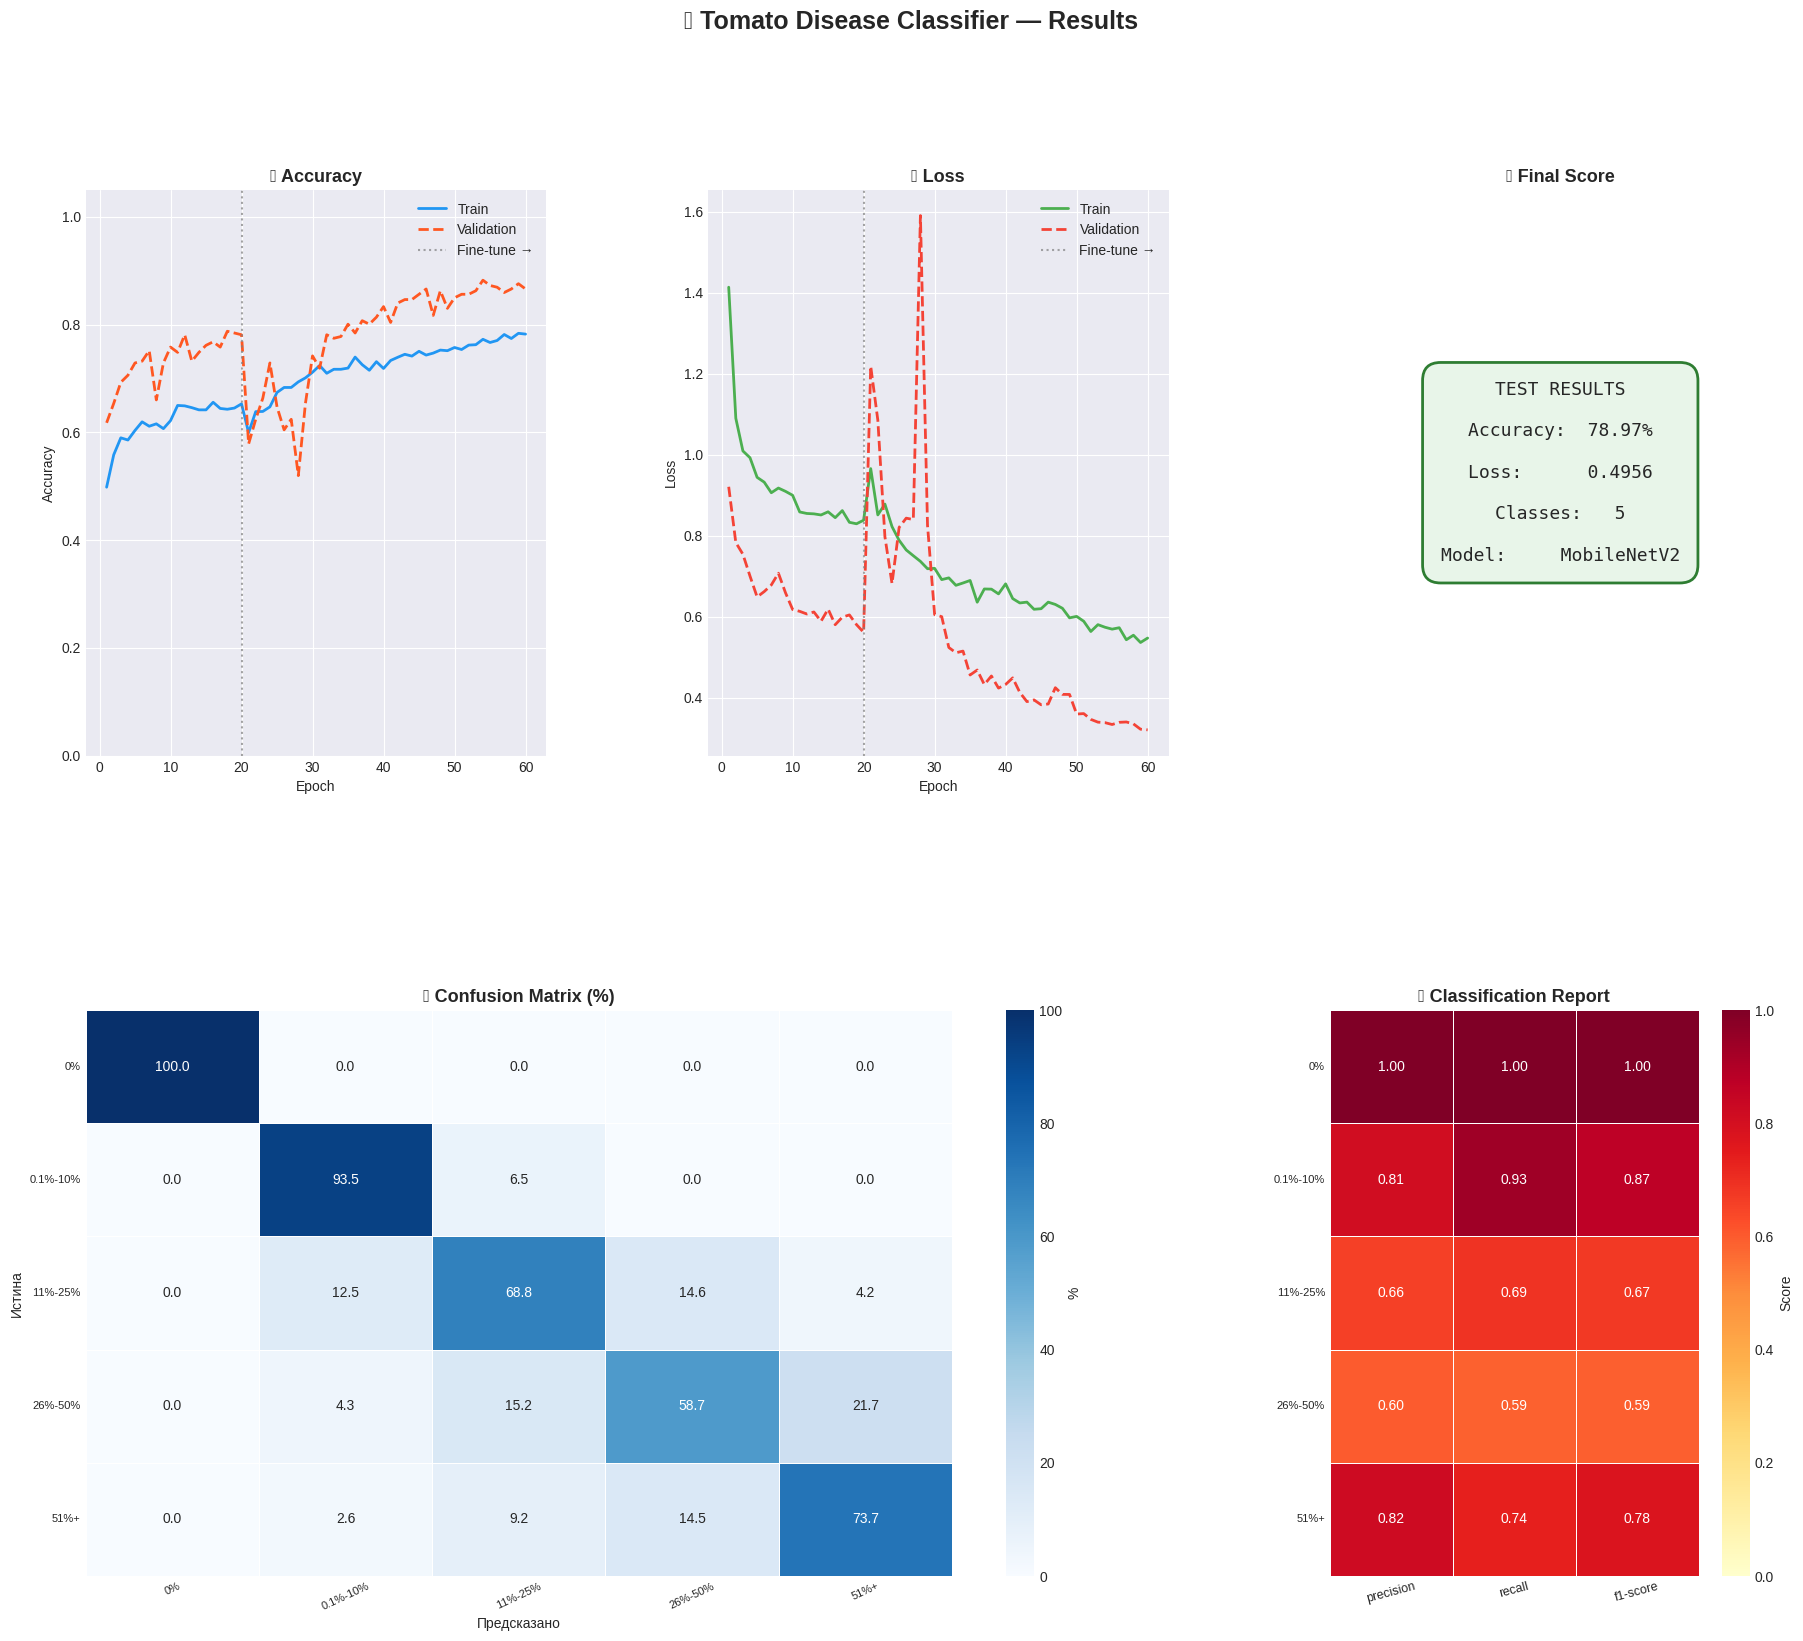


✅ График сохранён:  training_results.png
✅ Модель сохранена: tomato_model.h5

══════════════════════════════════════════════════
              precision    recall  f1-score   support

          0%       1.00      1.00      1.00        55
    0.1%-10%       0.81      0.93      0.87        46
     11%-25%       0.66      0.69      0.67        48
     26%-50%       0.60      0.59      0.59        46
        51%+       0.82      0.74      0.78        76

    accuracy                           0.79       271
   macro avg       0.78      0.79      0.78       271
weighted avg       0.79      0.79      0.79       271



In [ ]:
# ── 9. ВИЗУАЛИЗАЦИЯ ───────────────────────
plt.style.use("seaborn-v0_8-darkgrid")
fig = plt.figure(figsize=(22, 18))
fig.suptitle("🍅 Tomato Disease Classifier — Results",
             fontsize=18, fontweight="bold")
gs = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.35)

# --- Accuracy ---
ax1 = fig.add_subplot(gs[0, 0])
ep = range(1, len(history["accuracy"]) + 1)
ax1.plot(ep, history["accuracy"],     color="#2196F3", lw=2, label="Train")
ax1.plot(ep, history["val_accuracy"], color="#FF5722", lw=2,
         linestyle="--", label="Validation")
ax1.axvline(x=len(h1.history["accuracy"]), color="gray",
            linestyle=":", alpha=0.7, label="Fine-tune →")
ax1.set_title("📈 Accuracy", fontsize=13, fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy")
ax1.legend(); ax1.set_ylim([0, 1.05])

# --- Loss ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(ep, history["loss"],     color="#4CAF50", lw=2, label="Train")
ax2.plot(ep, history["val_loss"], color="#F44336", lw=2,
         linestyle="--", label="Validation")
ax2.axvline(x=len(h1.history["loss"]), color="gray",
            linestyle=":", alpha=0.7, label="Fine-tune →")
ax2.set_title("📉 Loss", fontsize=13, fontweight="bold")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
ax2.legend()

# --- Score Box ---
ax3 = fig.add_subplot(gs[0, 2])
ax3.axis("off")
ax3.text(0.5, 0.5,
    f"TEST RESULTS\n\n"
    f"Accuracy:  {test_acc*100:.2f}%\n\n"
    f"Loss:      {test_loss:.4f}\n\n"
    f"Classes:   {NUM_CLASSES}\n\n"
    f"Model:     MobileNetV2",
    transform=ax3.transAxes, fontsize=13,
    va="center", ha="center", fontfamily="monospace",
    bbox=dict(boxstyle="round,pad=1", facecolor="#E8F5E9",
              edgecolor="#2E7D32", linewidth=2)
)
ax3.set_title("🏆 Final Score", fontsize=13, fontweight="bold")

# --- Confusion Matrix ---
ax4 = fig.add_subplot(gs[1, :2])
cm = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
short = [n[:18] for n in CLASS_NAMES]
sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=short, yticklabels=short,
            linewidths=0.5, ax=ax4, cbar_kws={"label": "%"})
ax4.set_title("🔲 Confusion Matrix (%)", fontsize=13, fontweight="bold")
ax4.set_ylabel("Истина"); ax4.set_xlabel("Предсказано")
ax4.tick_params(axis="x", rotation=25, labelsize=8)
ax4.tick_params(axis="y", rotation=0,  labelsize=8)

# --- Classification Report ---
ax5 = fig.add_subplot(gs[1, 2])
rpt = classification_report(y_true, y_pred,
      target_names=CLASS_NAMES, output_dict=True, zero_division=0)
rdf = pd.DataFrame(
    {k: [rpt[c][k] for c in CLASS_NAMES]
     for k in ["precision", "recall", "f1-score"]},
    index=[n[:15] for n in CLASS_NAMES]
)
sns.heatmap(rdf, annot=True, fmt=".2f", cmap="YlOrRd",
            vmin=0, vmax=1, linewidths=0.5, ax=ax5,
            cbar_kws={"label": "Score"})
ax5.set_title("📋 Classification Report", fontsize=13, fontweight="bold")
ax5.tick_params(axis="x", rotation=15, labelsize=9)
ax5.tick_params(axis="y", rotation=0,  labelsize=8)

out_img = "training_results.png"
plt.savefig(out_img, dpi=150, bbox_inches="tight")
plt.show()

print(f"\n✅ График сохранён:  {out_img}")
print(f"✅ Модель сохранена: {MODEL_PATH}")
print("\n" + "═"*50)
print(classification_report(y_true, y_pred,
      target_names=CLASS_NAMES, zero_division=0))

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf
from tensorflow.keras.models import load_model
from PIL import Image

# ──────────────────────────────────────────
#  ⚙️  НАСТРОЙКИ — поменяй эти два пути
# ──────────────────────────────────────────
MODEL_PATH = "tomato_model.h5"   # путь к .h5 файлу
DATA_DIR   = "/content/drive/MyDrive/dataset_tomato" # Добавляем определение DATA_DIR
TEST_DIR   = os.path.join(DATA_DIR, "test")       # папка test с подпапками классов
IMG_SIZE   = (224, 224)
# ──────────────────────────────────────────


# ── Шаг 1: Проверка файлов ────────────────
print("=" * 55)
print("  🍅  Tomato Disease — Тестирование модели")
print("=" * 55)

if not os.path.exists(MODEL_PATH):
    print(f"\n❌ ОШИБКА: модель не найдена → {MODEL_PATH}")
    print("   Сначала запусти train_model.py\n")
    raise FileNotFoundError(f"Model file not found: {MODEL_PATH}")

if not os.path.exists(TEST_DIR):
    print(f"\n❌ ОШИБКА: папка test не найдена → {TEST_DIR}")
    print("   Проверь путь TEST_DIR в настройках\n")
    raise FileNotFoundError(f"Test directory not found: {TEST_DIR}")

print(f"\n✅ Модель найдена:     {MODEL_PATH}")
print(f"✅ Папка test найдена: {TEST_DIR}")


# ── Шаг 2: Загрузка модели ────────────────
print("\n🔄 Загружаю модель...")
model = load_model(MODEL_PATH)
print("✅ Модель загружена!")


# ── Шаг 3: Получение классов ──────────────
class_names = sorted([
    d for d in os.listdir(TEST_DIR)
    if os.path.isdir(os.path.join(TEST_DIR, d))
])
print(f"\n📦 Найдено классов: {len(class_names)}")
for i, c in enumerate(class_names):
    print(f"   [{i}] {c}")


# ── Шаг 4: Сбор всех изображений ──────────
all_images = []
exts = (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG", ".bmp")

for cls in class_names:
    cls_dir = os.path.join(TEST_DIR, cls)
    files = [
        os.path.join(cls_dir, f)
        for f in os.listdir(cls_dir)
        if f.endswith(exts)
    ]
    for fp in files:
        all_images.append((fp, cls))

print(f"\n🖼️  Всего изображений в test: {len(all_images)}")

if len(all_images) == 0:
    print("❌ Изображения не найдены! Проверь папку test/")
    raise ValueError("No images found in the test directory.")

# Случайно выбираем 6–10 фото
num_photos = random.randint(6, min(10, len(all_images)))
selected   = random.sample(all_images, num_photos)
print(f"🎲 Случайно выбрано: {num_photos} фото\n")


# ── Шаг 5: Функция предсказания ───────────
def predict_one(img_path):
    pil_img = Image.open(img_path).convert("RGB").resize(IMG_SIZE)
    arr = np.array(pil_img, dtype="float32") / 255.0
    arr = np.expand_dims(arr, axis=0)
    probs    = model.predict(arr, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    return {
        "pil_img":   pil_img,
        "pred_cls":  class_names[pred_idx],
        "pred_conf": float(probs[pred_idx]) * 100,
        "all_probs": probs,
    }


# ── Шаг 6: Предсказания ───────────────────
print("—" * 55)
print(f"{'Файл':<28} {'Истина':<20} {'Предсказано':<20} {'%':>6}")
print("—" * 55)

results = []
for img_path, true_cls in selected:
    res = predict_one(img_path)
    res["true_cls"] = true_cls
    res["img_path"] = img_path
    res["correct"]  = (true_cls == res["pred_cls"])
    results.append(res)

    icon = "✅" if res["correct"] else "❌"
    fname = os.path.basename(img_path)[:26]
    print(f"{icon} {fname:<26} {true_cls[:18]:<20} "
          f"{res['pred_cls'][:18]:<20} {res['pred_conf']:>5.1f}%")

print("—" * 55)
correct_count = sum(r["correct"] for r in results)
print(f"\n🎯 Результат: {correct_count}/{num_photos} правильно  "
      f"({correct_count/num_photos*100:.0f}%) রাহুল\n")


# ── Шаг 7: График 1 — Фото с предсказаниями ──
cols = 3
rows = (num_photos + cols - 1) // cols

fig1, axes = plt.subplots(rows, cols, figsize=(16, rows * 5.2))
fig1.suptitle(
    f"🍅 Tomato Disease — Предсказания ({num_photos} фото)",
    fontsize=15, fontweight="bold", y=1.01
)
axes_flat = axes.flatten() if hasattr(axes, "flatten") else [axes]

for i, res in enumerate(results):
    ax = axes_flat[i]
    ax.imshow(res["pil_img"])
    ax.axis("off")

    color = "#27AE60" if res["correct"] else "#C0392B"
    icon  = "✅" if res["correct"] else "❌"

    ax.set_title(
        f"{icon}  {res['pred_cls'][:22]}\n"
        f"Истина: {res['true_cls'][:22]}\n"
        f"Уверенность: {res['pred_conf']:.1f}%",
        fontsize=9, color=color, fontweight="bold",
        pad=5, linespacing=1.5
    )
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(3)
        spine.set_edgecolor(color)

for j in range(len(results), len(axes_flat)):
    axes_flat[j].axis("off")

plt.tight_layout()
plt.savefig("predictions_grid.png", dpi=150, bbox_inches="tight")
print("💾 Сохранено: predictions_grid.png")


# ── Шаг 8: График 2 — Топ-3 вероятности ──
fig2, axes2 = plt.subplots(rows, cols, figsize=(18, rows * 4))
fig2.suptitle(
    "📊 Топ-3 вероятности для каждого фото",
    fontsize=15, fontweight="bold"
)
axes2_flat = axes2.flatten() if hasattr(axes2, "flatten") else [axes2]

for i, res in enumerate(results):
    ax = axes2_flat[i]

    top3_idx  = np.argsort(res["all_probs"])[::-1][:3]
    top3_prob = res["all_probs"][top3_idx] * 100
    top3_name = [class_names[j][:20] for j in top3_idx]

    bar_colors = []
    for j, idx in enumerate(top3_idx):
        if class_names[idx] == res["true_cls"]:
            bar_colors.append("#2ECC71")
        elif j == 0:
            bar_colors.append("#E74C3C")
        else:
            bar_colors.append("#AEB6BF")

    bars = ax.barh(range(3), top3_prob,
                   color=bar_colors, edgecolor="white", height=0.6)

    for bar, prob in zip(bars, top3_prob):
        ax.text(
            bar.get_width() + 0.8,
            bar.get_y() + bar.get_height() / 2,
            f"{prob:.1f}%",
            va="center", fontsize=9, fontweight="bold"
        )

    ax.set_yticks(range(3))
    ax.set_yticklabels(top3_name, fontsize=8)
    ax.set_xlim(0, 118)
    ax.set_xlabel("Вероятность (%)", fontsize=8)
    ax.invert_yaxis()
    ax.axvline(x=50, color="gray", linestyle="--", alpha=0.35, linewidth=1)

    icon  = "✅" if res["correct"] else "❌"
    fname = os.path.basename(res["img_path"])[:28]
    ax.set_title(f"{icon} {fname}", fontsize=8, fontweight="bold")

for j in range(len(results), len(axes2_flat)):
    axes2_flat[j].axis("off")

green_p = mpatches.Patch(color="#2ECC71", label="Правильный класс")
red_p   = mpatches.Patch(color="#E74C3C", label="Неверное предсказание (топ-1)")
gray_p  = mpatches.Patch(color="#AEB6BF", label="Другие классы")
fig2.legend(
    handles=[green_p, red_p, gray_p],
    loc="lower center", ncol=3, fontsize=10,
    bbox_to_anchor=(0.5, -0.03)
)

plt.tight_layout()
plt.savefig("predictions_probs.png", dpi=150, bbox_inches="tight")
print("💾 Сохранено: predictions_probs.png")

plt.show()

print("\n" + "=" * 55)
print(f"  ✅  Готово! Правильно: {correct_count}/{num_photos}")
print("=" * 55)

NameError: name 'DATA_DIR' is not defined